In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/포트폴리오 자료/healthcare_noshows(원본).csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106987 entries, 0 to 106986
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       106987 non-null  float64
 1   AppointmentID   106987 non-null  int64  
 2   Gender          106987 non-null  object 
 3   ScheduledDay    106987 non-null  object 
 4   AppointmentDay  106987 non-null  object 
 5   Age             106987 non-null  int64  
 6   Neighbourhood   106987 non-null  object 
 7   Scholarship     106987 non-null  bool   
 8   Hipertension    106987 non-null  bool   
 9   Diabetes        106987 non-null  bool   
 10  Alcoholism      106987 non-null  bool   
 11  Handcap         106987 non-null  bool   
 12  SMS_received    106987 non-null  bool   
 13  Showed_up       106987 non-null  bool   
 14  Date.diff       106987 non-null  int64  
dtypes: bool(7), float64(1), int64(3), object(4)
memory usage: 7.2+ MB


문제: 병원 예약 후 환자가 방문하지 않는 문제 (No-show)

목표: 환자가 예약을 지킬지(No-show 여부)를 예측하여 해결


Reducing Medical Appointment No-Shows
Using Machine Learning and Patient Behavior Analysis

##1. 전처리

In [5]:
df.head()

#칼럼별 전처리 계획
# PatientId, AppointmentID -> 삭제
# ScheduledDay, AppointmentDay -> 파생변수로 변경 (scheduled_weekday, appointment_weekday)
# Date.diff -> 음수 제거
# 질병 (Hipertension	Diabetes	Alcoholism) -> 하나로 합산, 이후 기존 칼럼은 제거
# 지역은 지역별 노쇼 비율 구하여 새로운 칼럼 생성
# 성별, 나이, 지원 여부, 장애 여부, SMS 수신 여부는 수정 X
# No-show 여부는 Showed_up에서 No_show 기준으로 수정
# bool형 변수는 전부 int형(0/1)으로 수정

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


In [6]:
#보기 편하게 showed_up칼럼을 No_show로 변경

# No-show 컬럼 생성
df["No_show"] = ~df["Showed_up"]

df = df.drop(columns=['Showed_up'])

In [7]:
# ID 컬럼 삭제 >> 환자 개개인을 분류하려는 식별자일 뿐 분석할 정보가 없는 데이터
# 단순 식별자, 패턴 없음, 모델 생성에 기여하지 않고 학습에 문제가 될 수 있음
df = df.drop(columns=['PatientId', 'AppointmentID'])

# 확인
df.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Date.diff,No_show
0,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,0,False
1,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,0,False
2,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,0,False
3,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,0,False
4,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,0,False


In [8]:
# 날짜형으로 변환 >> 원본 날짜의 경우 모델 입력에 적절하지 않음 -> 파생 변수로 변경
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# 확인
df.dtypes

,0
Gender,object
ScheduledDay,datetime64[ns]
AppointmentDay,datetime64[ns]
Age,int64
Neighbourhood,object
Scholarship,bool
Hipertension,bool
Diabetes,bool
Alcoholism,bool
Handcap,bool


In [9]:
# 예약 요일 >> 파생 변수를 통해 환자 예약 행동 패턴을 설명하는 변수로 활용될 수 있음
# Monday = 0
df['scheduled_weekday'] = df['ScheduledDay'].dt.weekday

# 진료 요일
df['appointment_weekday'] = df['AppointmentDay'].dt.weekday

df.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday
0,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,0,False,4,4
1,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,0,False,4,4
2,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,0,False,4,4
3,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,0,False,4,4
4,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,0,False,4,4


In [10]:
df = df.drop(columns=['ScheduledDay', 'AppointmentDay'])

df.head()

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday
0,F,62,JARDIM DA PENHA,False,True,False,False,False,False,0,False,4,4
1,M,56,JARDIM DA PENHA,False,False,False,False,False,False,0,False,4,4
2,F,62,MATA DA PRAIA,False,False,False,False,False,False,0,False,4,4
3,F,8,PONTAL DE CAMBURI,False,False,False,False,False,False,0,False,4,4
4,F,56,JARDIM DA PENHA,False,True,True,False,False,False,0,False,4,4


In [11]:
# 음수 제거
df = df[df['Date.diff'] >= 0]
# 일부 데이터에서 예약일보다 진료일이 빠른 경우(Date.diff < 0)가 확인.
# 이는 병원 예약 시스템의 기록 오류 또는 데이터 입력 시점 차이로 인해 발생한 것으로 판단.
# 이러한 값은 실제 대기 기간을 의미하지 않기 때문에 분석의 일관성을 위해 해당 데이터를 제거하였다.

# 확인
df['Date.diff'].describe()

,Date.diff
count,106982.000000
mean,10.167290
std,15.263631
min,0.000000
25%,0.000000
50%,4.000000
75%,14.000000
max,179.000000


In [12]:
# 환자의 전반적인 건강 상태를 보다 직관적으로 표현하기 위해 해당 변수들을 합산

df['chronic_score'] = (
    df['Hipertension'].astype(int)
    + df['Diabetes'].astype(int)
    + df['Alcoholism'].astype(int)
    + df['Handcap'].astype(int)
)

In [13]:
#bool형 변수들 int형으로 변환

bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

In [14]:
df.head()

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday,chronic_score
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,4,4,1
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,4,4,0
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,4,4,0
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,4,4,0
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,4,4,2


In [15]:
# 전체 노쇼 비율
df["No_show"].mean()

np.float64(0.20260417640350714)

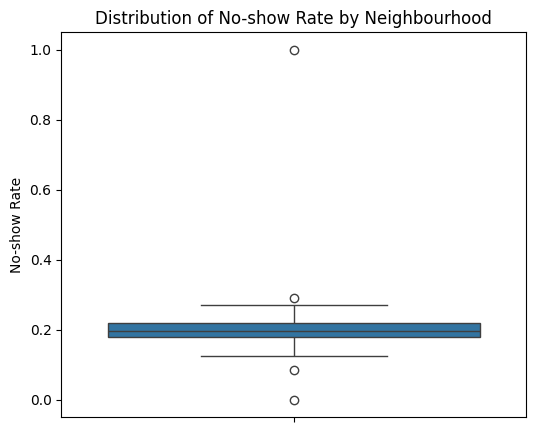

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 지역별 No-show 비율 확인 >> 1. box plot으로 이상치 확인, No-show 비율 분포 범위 확인
region_stats = df.groupby("Neighbourhood")["No_show"].mean()

plt.figure(figsize=(6,5))
sns.boxplot(y=region_stats)

plt.title("Distribution of No-show Rate by Neighbourhood")
plt.ylabel("No-show Rate")

plt.show()

In [17]:
#지역별 No-show 비율 확인 >> 2. 표본 수가 적은 지역 제거 (분석의 신뢰성을 위해)

region_stats = df.groupby('Neighbourhood').agg(
    patient_count=('Neighbourhood','count'),
    noshow_rate=('No_show','mean')
).sort_values('noshow_rate', ascending=False)

region_stats.head(20)

,patient_count,noshow_rate
Neighbourhood,,
ILHAS OCEÂNICAS DE TRINDADE,2,1.000000
SANTOS DUMONT,1249,0.291433
SANTA CECÍLIA,443,0.270880
SANTA CLARA,496,0.266129
ITARARÉ,3412,0.263189
JESUS DE NAZARETH,2719,0.248621
ILHA DO PRÍNCIPE,2222,0.236274
CARATOÍRA,2489,0.235436
ANDORINHAS,2195,0.231891


In [18]:
# 지역별 환자 수 계산
region_count = df.groupby("Neighbourhood").size()
# 최소 환자 수 기준 설정
min_patient = 100
# 환자 수가 충분한 지역만 선택
valid_regions = region_count[region_count >= min_patient].index
# 데이터에서 해당 지역만 남기기
df = df[df["Neighbourhood"].isin(valid_regions)]
# 지역별 노쇼 평균 계산
region_noshow_rate = df.groupby("Neighbourhood")["No_show"].mean()
# 새로운 feature 생성
df["region_noshow_rate"] = df["Neighbourhood"].map(region_noshow_rate)
# 결과 확인
df[["Neighbourhood", "region_noshow_rate"]].head()

,Neighbourhood,region_noshow_rate
0,JARDIM DA PENHA,0.162815
1,JARDIM DA PENHA,0.162815
2,MATA DA PRAIA,0.171340
4,JARDIM DA PENHA,0.162815
5,REPÚBLICA,0.171779


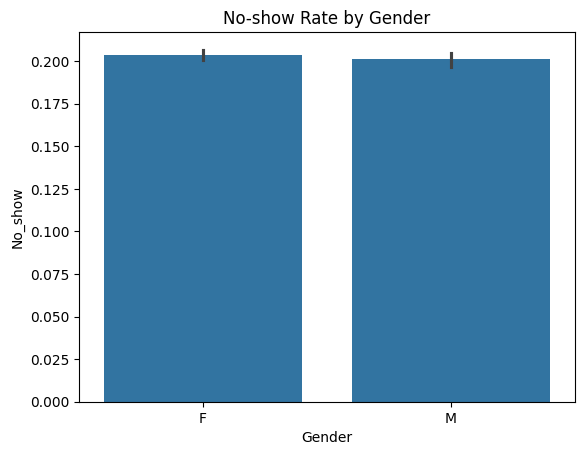

In [19]:
#성별 비율 및 성병 노쇼 비율 확인 후 int형 변환
#-> 차이가 거의 없음, 그러나 변수 하나 추가한다고 비용이 많이 드는 것도 아니고, 다른 변수와의 상관관계가 있을 수 있으니까 일단 Feature에 추가
sns.barplot(x="Gender", y="No_show", data=df)

plt.title("No-show Rate by Gender")
plt.show()

In [20]:
df.groupby("Gender")["No_show"].mean()

df["gender_binary"] = df["Gender"].map({"F":0, "M":1})

In [21]:
df

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday,chronic_score,region_noshow_rate,gender_binary
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,4,4,1,0.162815,0
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,4,4,0,0.162815,1
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,4,4,0,0.171340,0
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,4,4,2,0.162815,0
5,F,76,REPÚBLICA,0,1,0,0,0,0,2,0,2,4,1,0.171779,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106982,F,56,MARIA ORTIZ,0,0,0,0,0,1,35,0,1,1,0,0.214632,0
106983,F,51,MARIA ORTIZ,0,0,0,0,0,1,35,0,1,1,0,0.214632,0
106984,F,21,MARIA ORTIZ,0,0,0,0,0,1,41,0,2,1,0,0.214632,0
106985,F,38,MARIA ORTIZ,0,0,0,0,0,1,41,0,2,1,0,0.214632,0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106763 entries, 0 to 106986
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Gender               106763 non-null  object 
 1   Age                  106763 non-null  int64  
 2   Neighbourhood        106763 non-null  object 
 3   Scholarship          106763 non-null  int64  
 4   Hipertension         106763 non-null  int64  
 5   Diabetes             106763 non-null  int64  
 6   Alcoholism           106763 non-null  int64  
 7   Handcap              106763 non-null  int64  
 8   SMS_received         106763 non-null  int64  
 9   Date.diff            106763 non-null  int64  
 10  No_show              106763 non-null  int64  
 11  scheduled_weekday    106763 non-null  int32  
 12  appointment_weekday  106763 non-null  int32  
 13  chronic_score        106763 non-null  int64  
 14  region_noshow_rate   106763 non-null  float64
 15  gender_binary        1

## 2. EDA

### 2-1. Heatmap을 통한 상관관계 확인

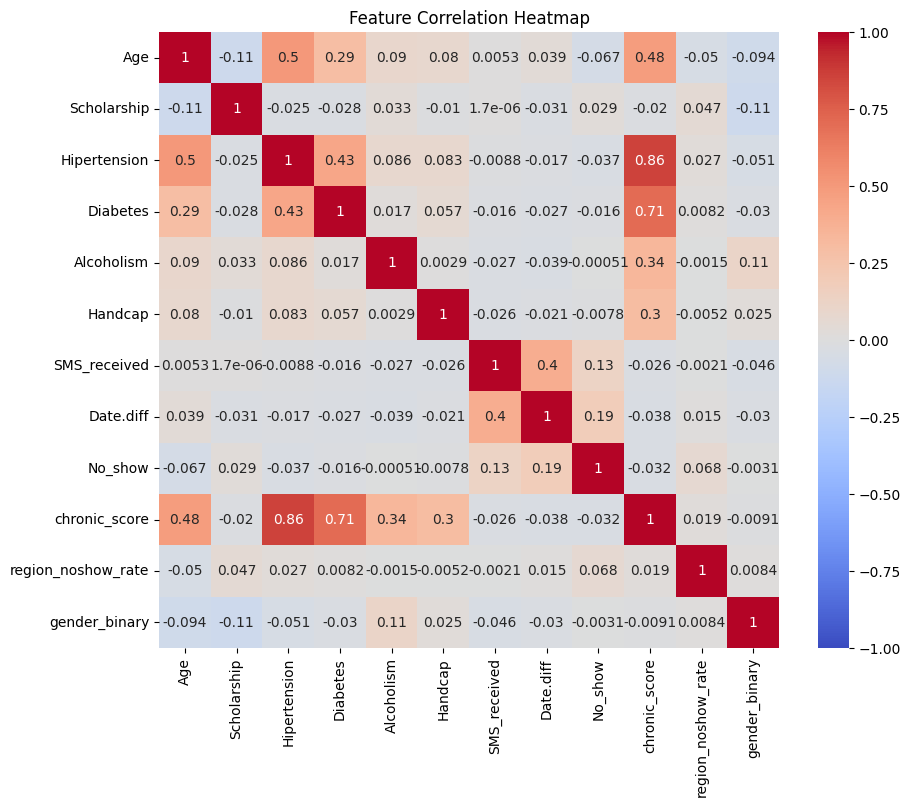

In [23]:
#숫자형 변수들 상관관계 확인

# 숫자형 컬럼만 선택
numeric_cols = df.select_dtypes(include=['int64','float64'])

# 상관계수 계산
corr = numeric_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Feature Correlation Heatmap")
plt.show()

* 질병 ↔ chronic_score간 상관관계 존재.

  → 이는 chronic_score만으로도 질병에서 얻을 수 있는 정보를 찾을 수 있기 때문에 질병에 관한 칼럼은 삭제해도 무관

In [24]:
df = df.drop(columns=['Hipertension', 'Diabetes', 'Alcoholism', 'Handcap'])

### 2-2. Date.diff와 No_show간 관계

<Axes: xlabel='No_show', ylabel='Date.diff'>

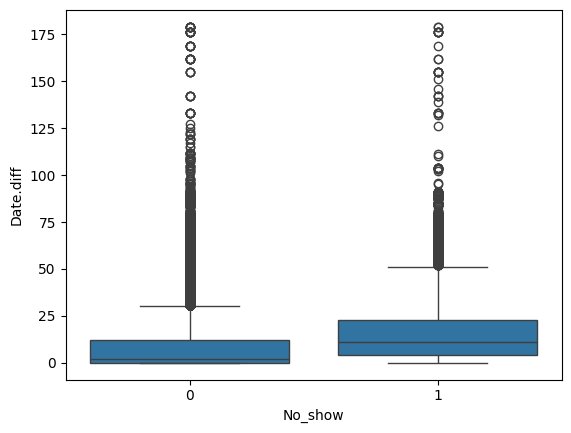

In [26]:
sns.boxplot(x="No_show", y="Date.diff", data=df)

* No_show가 1일 때 Date.diff의 값이 크고, 중앙값 역시 큼
  → 예약 대기시간이 길수록 No-show 확률이 증가


/tmp/ipykernel_40194/3248944853.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  date_noshow = df.groupby("Date_diff_group")["No_show"].mean().reset_index()


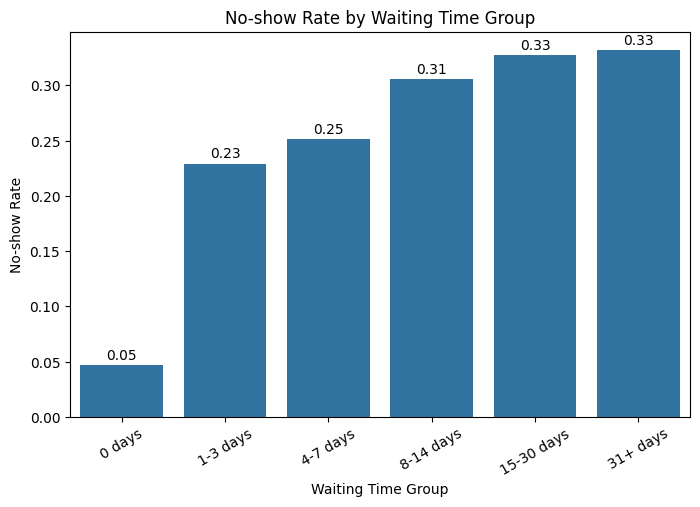

In [27]:
# Date.diff 구간 정의
bins = [-1, 0, 3, 7, 14, 30, df["Date.diff"].max()]
labels = ["0 days", "1-3 days", "4-7 days", "8-14 days", "15-30 days", "31+ days"]

df["Date_diff_group"] = pd.cut(df["Date.diff"], bins=bins, labels=labels)

# 구간별 No-show 비율 계산
date_noshow = df.groupby("Date_diff_group")["No_show"].mean().reset_index()

# 시각화
plt.figure(figsize=(8,5))
ax = sns.barplot(x="Date_diff_group", y="No_show", data=date_noshow)

for i, v in enumerate(date_noshow["No_show"]):
    ax.text(i, v + 0.005, f"{v:.2f}", ha="center")

plt.title("No-show Rate by Waiting Time Group")
plt.xlabel("Waiting Time Group")
plt.ylabel("No-show Rate")
plt.xticks(rotation=30)

plt.show()

In [28]:
date_count = df["Date_diff_group"].value_counts().sort_index()
print(date_count)

Date_diff_group
0 days        37090
1-3 days      14255
4-7 days      17115
8-14 days     11614
15-30 days    16696
31+ days       9993
Name: count, dtype: int64


### 2-3. SMS_received와 No_show 관계

<Axes: xlabel='SMS_received', ylabel='No_show'>

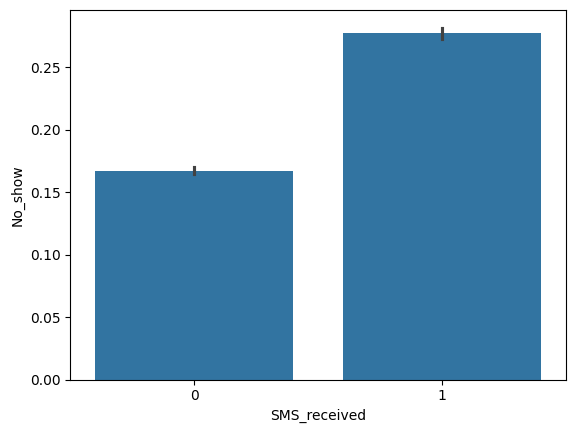

In [29]:
sns.barplot(x="SMS_received", y="No_show", data=df)

*  SMS를 수신한 환자의 No-show 비율이 높음. confounding bias일 수도 있기 때문에 환자 특성에 맞춰 추가 분석 필요

###2-3-1. Age와 No_show 관계

In [30]:
#나이대별로 그룹 분류

import pandas as pd

bins = [0, 12, 19, 39, 59, 120]
labels = ["Child (0-12)", "Teen (13-19)", "Young Adult (20-39)", "Middle Age (40-59)", "Senior (60+)"]

df["Age_group"] = pd.cut(df["Age"], bins=bins, labels=labels)

/tmp/ipykernel_40194/3327510789.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sms_rate = df.groupby("Age_group")["SMS_received"].mean().reset_index()


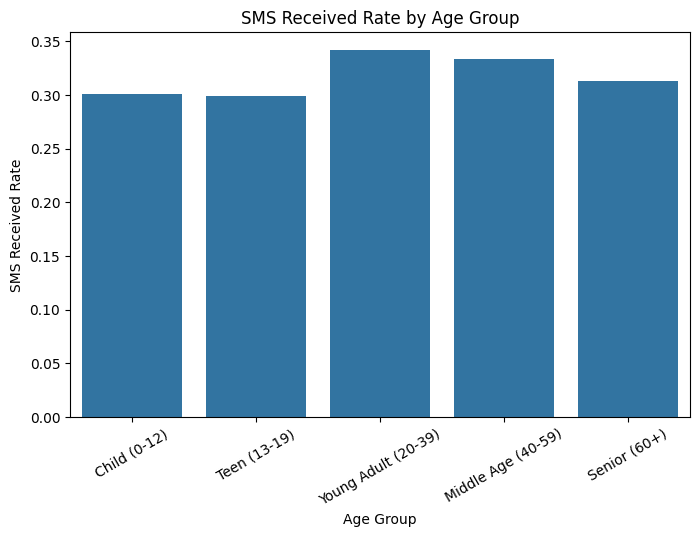

In [31]:
#나이대별 SMS 수신 비율

sms_rate = df.groupby("Age_group")["SMS_received"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Age_group", y="SMS_received", data=sms_rate)

plt.title("SMS Received Rate by Age Group")
plt.ylabel("SMS Received Rate")
plt.xlabel("Age Group")

plt.xticks(rotation=30)
plt.show()

나이대별 SMS 수신 비율은 비슷함

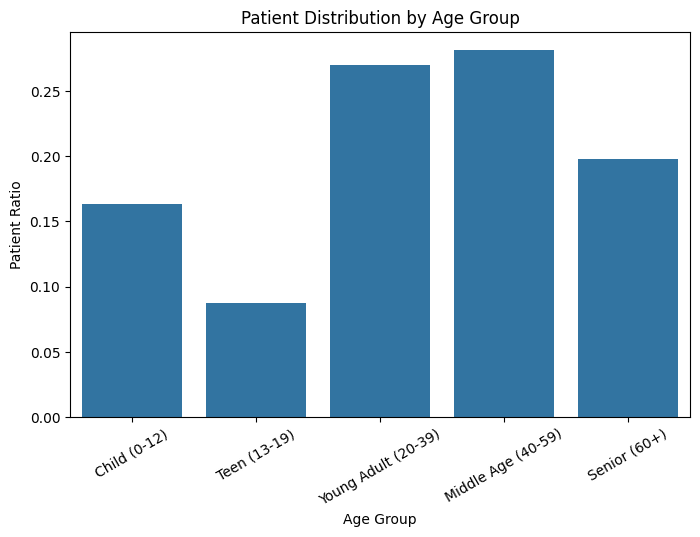

In [34]:
#나이대별 환자 비율

age_distribution = df["Age_group"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=age_distribution.index, y=age_distribution.values)

plt.title("Patient Distribution by Age Group")
plt.ylabel("Patient Ratio")
plt.xlabel("Age Group")

plt.xticks(rotation=30)
plt.show()

/tmp/ipykernel_40194/629285766.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chronic_by_age = df.groupby("Age_group")["chronic_score"].mean().reset_index()


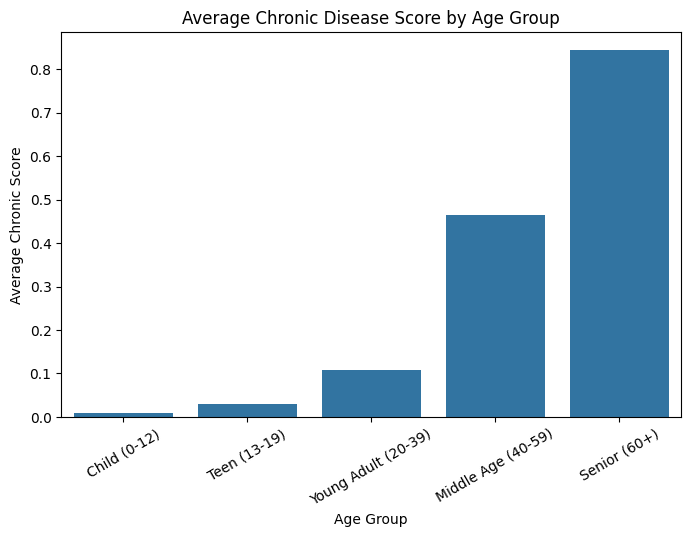

In [35]:
#나이대별 질병 개수 평균

chronic_by_age = df.groupby("Age_group")["chronic_score"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Age_group", y="chronic_score", data=chronic_by_age)

plt.title("Average Chronic Disease Score by Age Group")
plt.ylabel("Average Chronic Score")
plt.xlabel("Age Group")

plt.xticks(rotation=30)
plt.show()

/tmp/ipykernel_40194/1255441956.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  noshow_age = df.groupby("Age_group")["No_show"].mean().reset_index()


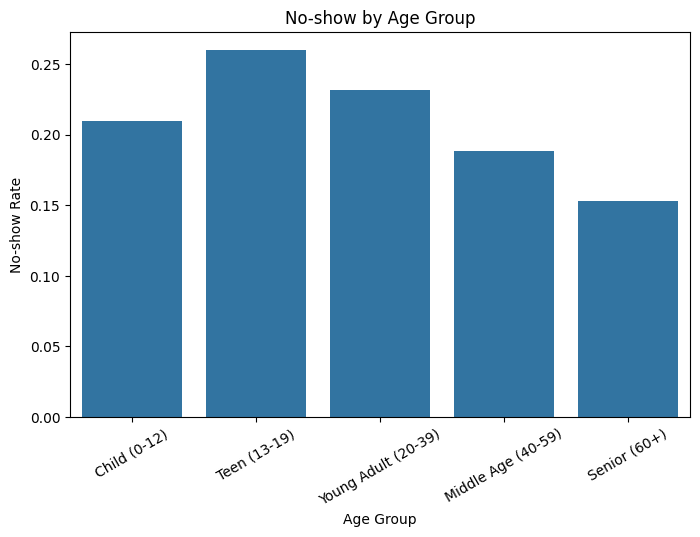

In [36]:
#나이대별 노쇼 여부
noshow_age = df.groupby("Age_group")["No_show"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Age_group", y="No_show", data=noshow_age)

plt.title("No-show by Age Group")
plt.ylabel("No-show Rate")
plt.xlabel("Age Group")

plt.xticks(rotation=30)
plt.show()

SMS 수신 여부보다는 Age로 인한 영향이 커 보임

###2-3-2. choronic_score과 No_show 관계

<Axes: xlabel='chronic_score', ylabel='No_show'>

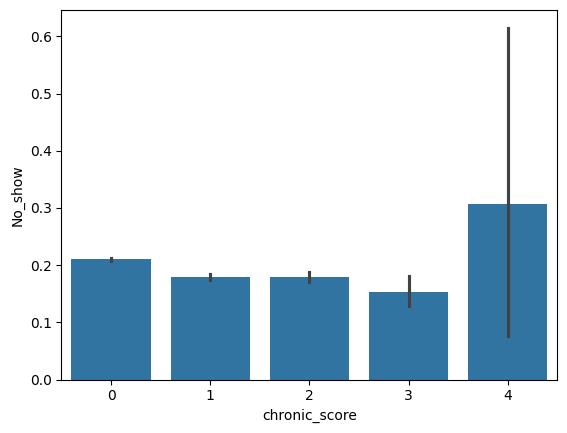

In [37]:
sns.barplot(x="chronic_score", y="No_show", data=df)

* 질병이 1~3개는 No-show율이 낮아지는데, 4에서 갑자기 튐 -> 표본이 적어서 튈 수 있으니 확인 필요

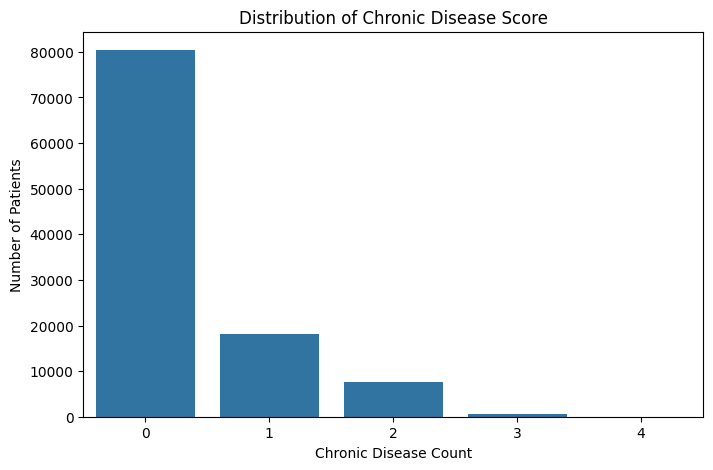

In [38]:
#질병 개수 분포
chronic_count = df["chronic_score"].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=chronic_count.index, y=chronic_count.values)

plt.title("Distribution of Chronic Disease Score")
plt.ylabel("Number of Patients")
plt.xlabel("Chronic Disease Count")

plt.show()

4개를 모두 가진 만성질환의 환자가 적어 데이터가 튄 것

###2-3-3. region_noshow_rate와 No_show 관계

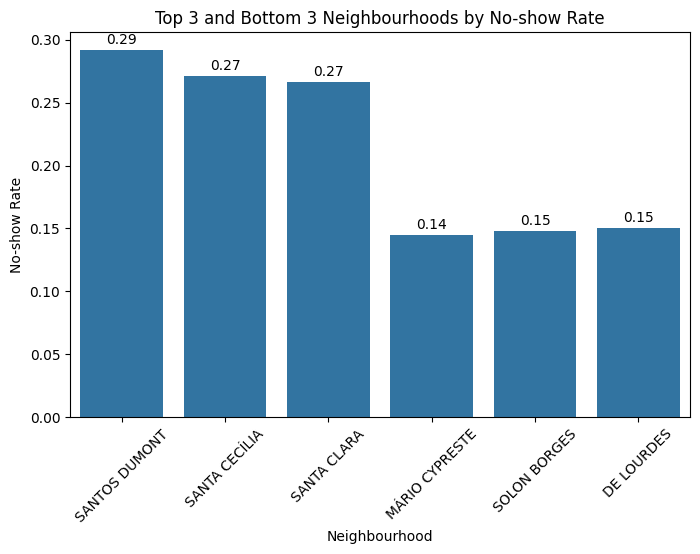

In [39]:
# 상위 3개 / 하위 3개 지역 추출
top3 = region_noshow_rate.sort_values(ascending=False).head(3)
bottom3 = region_noshow_rate.sort_values().head(3)

# 하나로 합치기
plot_data = pd.concat([top3, bottom3]).reset_index()
plot_data.columns = ["Neighbourhood", "No_show_rate"]

# 시각화
plt.figure(figsize=(8,5))
sns.barplot(data=plot_data, x="Neighbourhood", y="No_show_rate")

# 막대 위에 노쇼율 수치 표시
for i, v in enumerate(plot_data["No_show_rate"]):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center', fontsize=10)

plt.title("Top 3 and Bottom 3 Neighbourhoods by No-show Rate")
plt.xlabel("Neighbourhood")
plt.ylabel("No-show Rate")
plt.xticks(rotation=45)

plt.show()

###2-4. scholarship과 No_show 관계

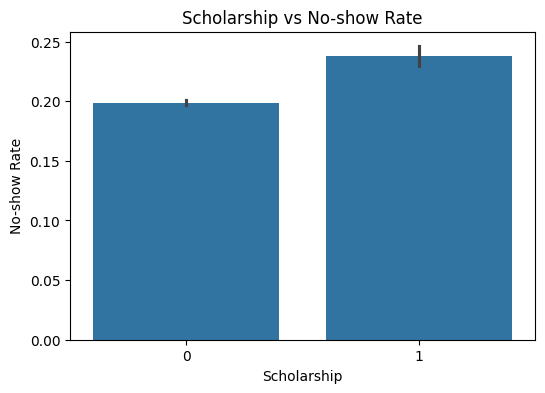

In [40]:
plt.figure(figsize=(6,4))

sns.barplot(x="Scholarship", y="No_show", data=df)

plt.title("Scholarship vs No-show Rate")
plt.ylabel("No-show Rate")
plt.xlabel("Scholarship")

plt.show()

* 지원 대상 환자 no=show가 높음. 그러나 0과 차이가 크지 않음

## 3. Feature Engineering

In [41]:
#Has Chronic Disease (binary)

df["has_chronic_disease"] = (df["chronic_score"] > 0).astype(int)

In [42]:
#SMS + Long Wait Interaction

df["long_wait"] = (df["Date.diff"] >= 14).astype(int)
df["sms_long_wait"] = df["SMS_received"] * df["long_wait"]

In [43]:
df.head()

,Gender,Age,Neighbourhood,Scholarship,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday,chronic_score,region_noshow_rate,gender_binary,Date_diff_group,Age_group,has_chronic_disease,long_wait,sms_long_wait
0,F,62,JARDIM DA PENHA,0,0,0,0,4,4,1,0.162815,0,0 days,Senior (60+),1,0,0
1,M,56,JARDIM DA PENHA,0,0,0,0,4,4,0,0.162815,1,0 days,Middle Age (40-59),0,0,0
2,F,62,MATA DA PRAIA,0,0,0,0,4,4,0,0.171340,0,0 days,Senior (60+),0,0,0
4,F,56,JARDIM DA PENHA,0,0,0,0,4,4,2,0.162815,0,0 days,Middle Age (40-59),1,0,0
5,F,76,REPÚBLICA,0,0,2,0,2,4,1,0.171779,0,1-3 days,Senior (60+),1,0,0


## 4. Model

* 데이터 누수 발생을 막기 위해 rigion_no_show_rate를 test, train 데이터로 나누어 다시 계산 (데이터 덮어씌움)

In [44]:
from sklearn.model_selection import train_test_split

# feature와 target 분리
X = df.drop(columns=["No_show"])
y = df["No_show"]

# train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, #일반적으로 많이 사용되는 80:20 비율을 적용
    random_state=42,
    stratify=y #노쇼 비율 유지
)

In [45]:
#train 기준 region no-show rate 계산
# train 데이터에 target 다시 붙이기

train_df = X_train.copy()
train_df["No_show"] = y_train

# region별 no-show 평균 계산 (train 기준)
region_rate = train_df.groupby("Neighbourhood")["No_show"].mean()

In [46]:
X_train["region_noshow_rate"] = X_train["Neighbourhood"].map(region_rate)

In [47]:
X_test["region_noshow_rate"] = X_test["Neighbourhood"].map(region_rate)

In [48]:
global_rate = y_train.mean()

X_test["region_noshow_rate"].fillna(global_rate, inplace=True)

/tmp/ipykernel_40194/2343809114.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test["region_noshow_rate"].fillna(global_rate, inplace=True)


In [49]:
X_train = X_train.drop(columns=["Neighbourhood"])
X_test = X_test.drop(columns=["Neighbourhood"])

In [50]:
print(X_train.columns)

Index(['Gender', 'Age', 'Scholarship', 'SMS_received', 'Date.diff',
       'scheduled_weekday', 'appointment_weekday', 'chronic_score',
       'region_noshow_rate', 'gender_binary', 'Date_diff_group', 'Age_group',
       'has_chronic_disease', 'long_wait', 'sms_long_wait'],
      dtype='object')


1) Logistic Regression

In [51]:
# Logistic Regression Baseline Model

# 필요한 라이브러리 불러오기
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# 1. 최종 feature
features = [
    "gender_binary",
    "Age",
    "Scholarship",
    "SMS_received",
    "Date.diff",
    "chronic_score",
    "sms_long_wait",
    "region_noshow_rate"
]

X_train_model = X_train[features].copy()
X_test_model = X_test[features].copy()

# 2. Logistic Regression용 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_model)

# 3. Logistic Regression 다시 학습
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)
import pandas as pd

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

log_model.fit(X_train_scaled, y_train)

# 예측
y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== Logistic Regression (Refined Features) ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 계수 확인
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("\n=== Logistic Regression Coefficients ===")
print(coef_df)

=== Logistic Regression (Refined Features) ===
Accuracy : 0.6551
Precision: 0.3167
Recall   : 0.6058
F1-score : 0.4159
ROC-AUC  : 0.6791

=== Confusion Matrix ===
[[11367  5658]
 [ 1706  2622]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.67      0.76     17025
           1       0.32      0.61      0.42      4328

    accuracy                           0.66     21353
   macro avg       0.59      0.64      0.59     21353
weighted avg       0.76      0.66      0.69     21353


=== Logistic Regression Coefficients ===
              Feature  Coefficient
4           Date.diff     0.506880
3        SMS_received     0.260375
7  region_noshow_rate     0.162561
2         Scholarship     0.056549
5       chronic_score     0.025231
0       gender_binary    -0.002644
6       sms_long_wait    -0.183970
1                 Age    -0.186570


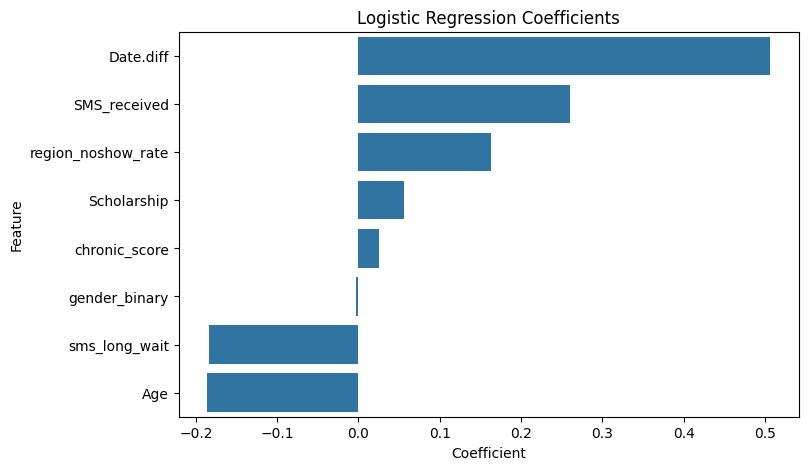

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature")

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

* 계수 해석

1. 가장 영향이 큰 변수 : Date.diff, 대기시간이 길수록 노쇼 확률 증가

2. SMS_reeived : SMS를 받을수록 No-show 비율이 높다

3. region_noshow_rate : 노쇼가 많은 지역에서 노쇼 확률이 높다는 건 Feature가 잘 작동한다는 증거

4. Age : 나이가 많을수록 노쇼 감소

5. sms_long_wait : 긴 대시시간 환자에게 SMS가 가면 노쇼 확률이 감소한다

### 2. Ramdom Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",   # No-show(1)가 적은 불균형 데이터라 가중치 보정
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_model, y_train)

# 예측 확률
y_pred_proba = rf_model.predict_proba(X_test_model)[:, 1]

# 기본 threshold = 0.5 결과
y_pred_default = (y_pred_proba >= 0.5).astype(int)

print("=== Random Forest (threshold=0.5) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_default):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_default):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_default))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_default))

=== Random Forest (threshold=0.5) ===
Accuracy : 0.6949
Precision: 0.3467
Recall   : 0.5716
F1-score : 0.4316
ROC-AUC  : 0.7295

=== Confusion Matrix ===
[[12364  4661]
 [ 1854  2474]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.73      0.79     17025
           1       0.35      0.57      0.43      4328

    accuracy                           0.69     21353
   macro avg       0.61      0.65      0.61     21353
weighted avg       0.76      0.69      0.72     21353



              Feature  Importance
4           Date.diff    0.431174
1                 Age    0.267363
7  region_noshow_rate    0.231006
3        SMS_received    0.023311
5       chronic_score    0.017221
0       gender_binary    0.012660
6       sms_long_wait    0.010847
2         Scholarship    0.006416


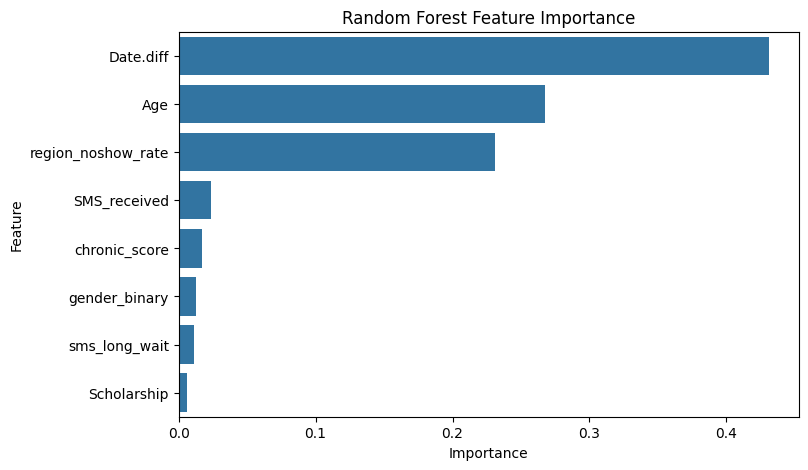

In [54]:
# Feature Importance 분석

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x="Importance", y="Feature")

plt.title("Random Forest Feature Importance")
plt.show()